In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from eval.data import load_and_split
from medal.model import AutoEncoder
from medal.normalizer import GlobalEmbeddingNormalizer
import torch
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
# Set MEDAL_DATA_DIR to the parent directory of your data (drd_data/ and MEDAL/ live here)
import os
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.expanduser('~'))
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-27 17:57:02,324	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-27 17:57:17,066	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

def plot_single_param_recon(student_embed,student_embed_test, per_sample_recon, per_sample_recon_test, labels, test_labels, fig, axes, palette, cmap, norm, plot_legend=False,
                            **fig_kwargs):
    if plot_legend:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=True, palette=palette)
        handles, labels = axes[0].get_legend_handles_labels()
        if getattr(axes[0], "legend_", None) is not None:
            axes[0].legend_.remove()

        # make one shared legend for the whole figure
        fig.legend(
            handles, labels,
            **fig_kwargs
        )
    else:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=False, palette=palette)
    sns.scatterplot(
        x=student_embed[:, 0].detach().numpy(), y=student_embed[:, 1].detach().numpy(),
        hue=per_sample_recon,
        palette=cmap, hue_norm=norm,
        s=8,legend=False, rasterized=True,
        ax=axes[1], 
    )
    sns.scatterplot(x=student_embed_test[:, 0].detach().numpy(), 
                    y=student_embed_test[:, 1].detach().numpy(),  
                    ax=axes[2], hue=test_labels, s=4, marker="x",linewidth=0.5, legend=False, alpha=1, palette=palette)
    sns.scatterplot(
        x=student_embed_test[:, 0].detach().numpy(), y=student_embed_test[:, 1].detach().numpy(),
        hue=per_sample_recon_test,
        palette=cmap, hue_norm=norm,marker="x",
        s=4, legend=False, rasterized=True,
        ax=axes[3], alpha=1, linewidth=0.5,
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test, 0.975)))
    fig.colorbar(sm, ax=axes[1], orientation="horizontal", fraction=0.05, pad=0.02)
    fig.colorbar(sm, ax=axes[3], orientation="horizontal", fraction=0.05, pad=0.02)

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

In [3]:
X_og, X_test, y_og, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
astro_palette = {digit: col for digit, col in zip(np.unique(y.flatten()), label_colors)}

## Hyperparameter Tuning

In [4]:
astro_tsne_res_dict = []
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(3), np.log10(500), 15).astype(int)):
        teacher_embed_raw = np.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_tsne_{perp}_train.npy")
        norm = GlobalEmbeddingNormalizer.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_tsne_{perp}_train.norm.pkl")
        teacher_embed = norm.transform(teacher_embed_raw)
        
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/medal_tsne2_{perp}_seed{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
            val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": val_recon, "split": "Val", "seed": s})
            
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


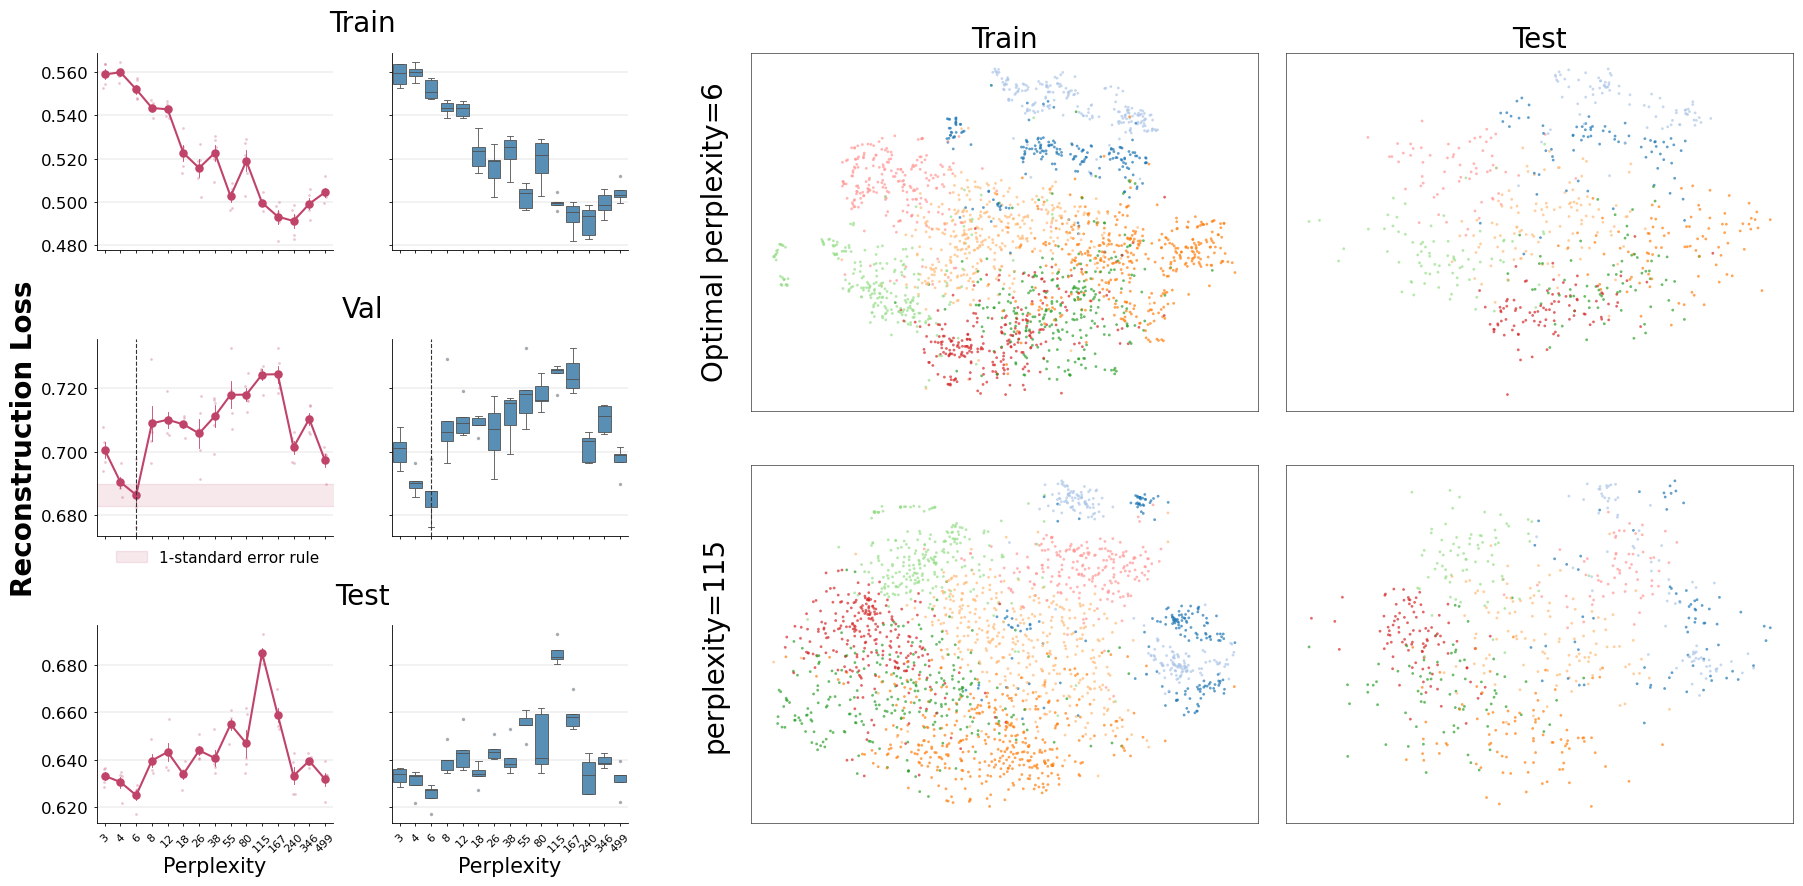

In [7]:
from utils import compute_param_choice, build_figure

# ── Compute parameter choice ────────────────────────────────────────────────────────────────────────────────
analysis, tsne_one_std_range, tsne_one_std_param_choice, unique_perplexities, vline_x = \
    compute_param_choice(astro_tsne_res_dict, 'perplexity')

# ── Load student models & compute embeddings ─────────────────────────────────────────────
list_tsne_param = [tsne_one_std_param_choice, 115]
student_tsne01 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/normalize/astro/medal_tsne2_{list_tsne_param[0]}_seed0_ckpts/final.pt',
                input_dim=19,
                hidden_dims=[512,512,512,512],
                latent_dim=2, batchnorm=False)
student_recon_tsne01, student_embed_tsne01 = student_tsne01(torch.tensor(X, dtype=torch.float32))
student_recon_val_tsne01, student_embed_val_tsne01 = student_tsne01(torch.tensor(X_val, dtype=torch.float32))
student_recon_test_tsne01, student_embed_test_tsne01 = student_tsne01(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_tsne01 = np.mean((student_recon_tsne01.detach().numpy() - X)**2, axis=1)
per_sample_recon_val_tsne01 = np.mean((student_recon_val_tsne01.detach().numpy() - X_val)**2, axis=1)
per_sample_recon_test_tsne01 = np.mean((student_recon_test_tsne01.detach().numpy() - X_test)**2, axis=1)

student_tsne02 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/normalize/astro/medal_tsne2_{list_tsne_param[1]}_seed0_ckpts/final.pt',
                input_dim=19,
                hidden_dims=[512,512,512,512],
                latent_dim=2, batchnorm=False)
student_recon_tsne02, student_embed_tsne02 = student_tsne02(torch.tensor(X, dtype=torch.float32))
student_recon_val_tsne02, student_embed_val_tsne02 = student_tsne02(torch.tensor(X_val, dtype=torch.float32))
student_recon_test_tsne02, student_embed_test_tsne02 = student_tsne02(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_tsne02 = np.mean((student_recon_tsne02.detach().numpy() - X)**2, axis=1)
per_sample_recon_val_tsne02 = np.mean((student_recon_val_tsne02.detach().numpy() - X_val)**2, axis=1)
per_sample_recon_test_tsne02 = np.mean((student_recon_test_tsne02.detach().numpy() - X_test)**2, axis=1)

# ── Figure ──────────────────────────────────────────────────────────────────────────────────────────────────────────
emb_data = {
    tsne_one_std_param_choice: {
        'Train': (student_embed_tsne01,      per_sample_recon_tsne01,      y),
        'Val':   (student_embed_val_tsne01,  per_sample_recon_val_tsne01,  y_val),
        'Test':  (student_embed_test_tsne01, per_sample_recon_test_tsne01, y_test),
    },
    list_tsne_param[1]: {
        'Train': (student_embed_tsne02,      per_sample_recon_tsne02,      y),
        'Val':   (student_embed_val_tsne02,  per_sample_recon_val_tsne02,  y_val),
        'Test':  (student_embed_test_tsne02, per_sample_recon_test_tsne02, y_test),
    },
}

build_figure(
    analysis, 'perplexity', unique_perplexities, tsne_one_std_range, vline_x,
    emb_data, list_tsne_param, tsne_one_std_param_choice,
    astro_palette, 'perplexity', 'Perplexity',
    row_label_y=1.15,
    legend_kw={'frameon': False, 'fontsize': 11, 'loc': 'best', 'bbox_to_anchor': (1, 0)},
    xtick_fontsize=8,figsize=(22, 10),
)

In [28]:
astro_umap_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed_raw = np.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_umap_{n}_0.1_train.npy")
        norm = GlobalEmbeddingNormalizer.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_umap_{n}_0.1_train.norm.pkl")
        teacher_embed = norm.transform(teacher_embed_raw)
        
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/medal_umap2_{n}_seed{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            astro_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
            val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
            astro_umap_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s})
            
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

# ── Compute parameter choice ────────────────────────────────────────────────────────────────────────────────
analysis, umap_one_std_range, umap_one_std_param_choice, unique_neighbors, vline_x = \
    compute_param_choice(astro_umap_res_dict, 'n_neighbors')

/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [15]:
list_umap_param = [umap_one_std_param_choice, 6]
student_umap01 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/normalize/astro/medal_umap2_{list_umap_param[0]}_seed0_ckpts/final.pt',
                input_dim=19,
                hidden_dims=[512,512,512, 512],
                latent_dim=2, batchnorm=False)
student_recon_umap01, student_embed_umap01 = student_umap01(torch.tensor(X, dtype=torch.float32))
student_recon_val_umap01, student_embed_val_umap01 = student_umap01(torch.tensor(X_val, dtype=torch.float32))
student_recon_test_umap01, student_embed_test_umap01 = student_umap01(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_umap01 = np.mean((student_recon_umap01.detach().numpy() - X)**2, axis=1)
per_sample_recon_val_umap01 = np.mean((student_recon_val_umap01.detach().numpy() - X_val)**2, axis=1)
per_sample_recon_test_umap01 = np.mean((student_recon_test_umap01.detach().numpy() - X_test)**2, axis=1)

student_umap02 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/normalize/astro/medal_umap2_{list_umap_param[1]}_seed0_ckpts/final.pt',
                input_dim=19,
                hidden_dims=[512,512,512, 512],
                latent_dim=2, batchnorm=False)
student_recon_umap02, student_embed_umap02 = student_umap02(torch.tensor(X, dtype=torch.float32))
student_recon_val_umap02, student_embed_val_umap02 = student_umap02(torch.tensor(X_val, dtype=torch.float32))
student_recon_test_umap02, student_embed_test_umap02 = student_umap02(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_umap02 = np.mean((student_recon_umap02.detach().numpy() - X)**2, axis=1)
per_sample_recon_val_umap02 = np.mean((student_recon_val_umap02.detach().numpy() - X_val)**2, axis=1)
per_sample_recon_test_umap02 = np.mean((student_recon_test_umap02.detach().numpy() - X_test)**2, axis=1)

# ── Figure ──────────────────────────────────────────────────────────────────────────────────────────────────────────
emb_data = {
    list_umap_param[0]: {
        'Train': (student_embed_umap01,      per_sample_recon_umap01,      y),
        'Val':   (student_embed_val_umap01,  per_sample_recon_val_umap01,  y_val),
        'Test':  (student_embed_test_umap01, per_sample_recon_test_umap01, y_test),
    },
    list_umap_param[1]: {
        'Train': (student_embed_umap02,      per_sample_recon_umap02,      y),
        'Val':   (student_embed_val_umap02,  per_sample_recon_val_umap02,  y_val),
        'Test':  (student_embed_test_umap02, per_sample_recon_test_umap02, y_test),
    },
}

/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


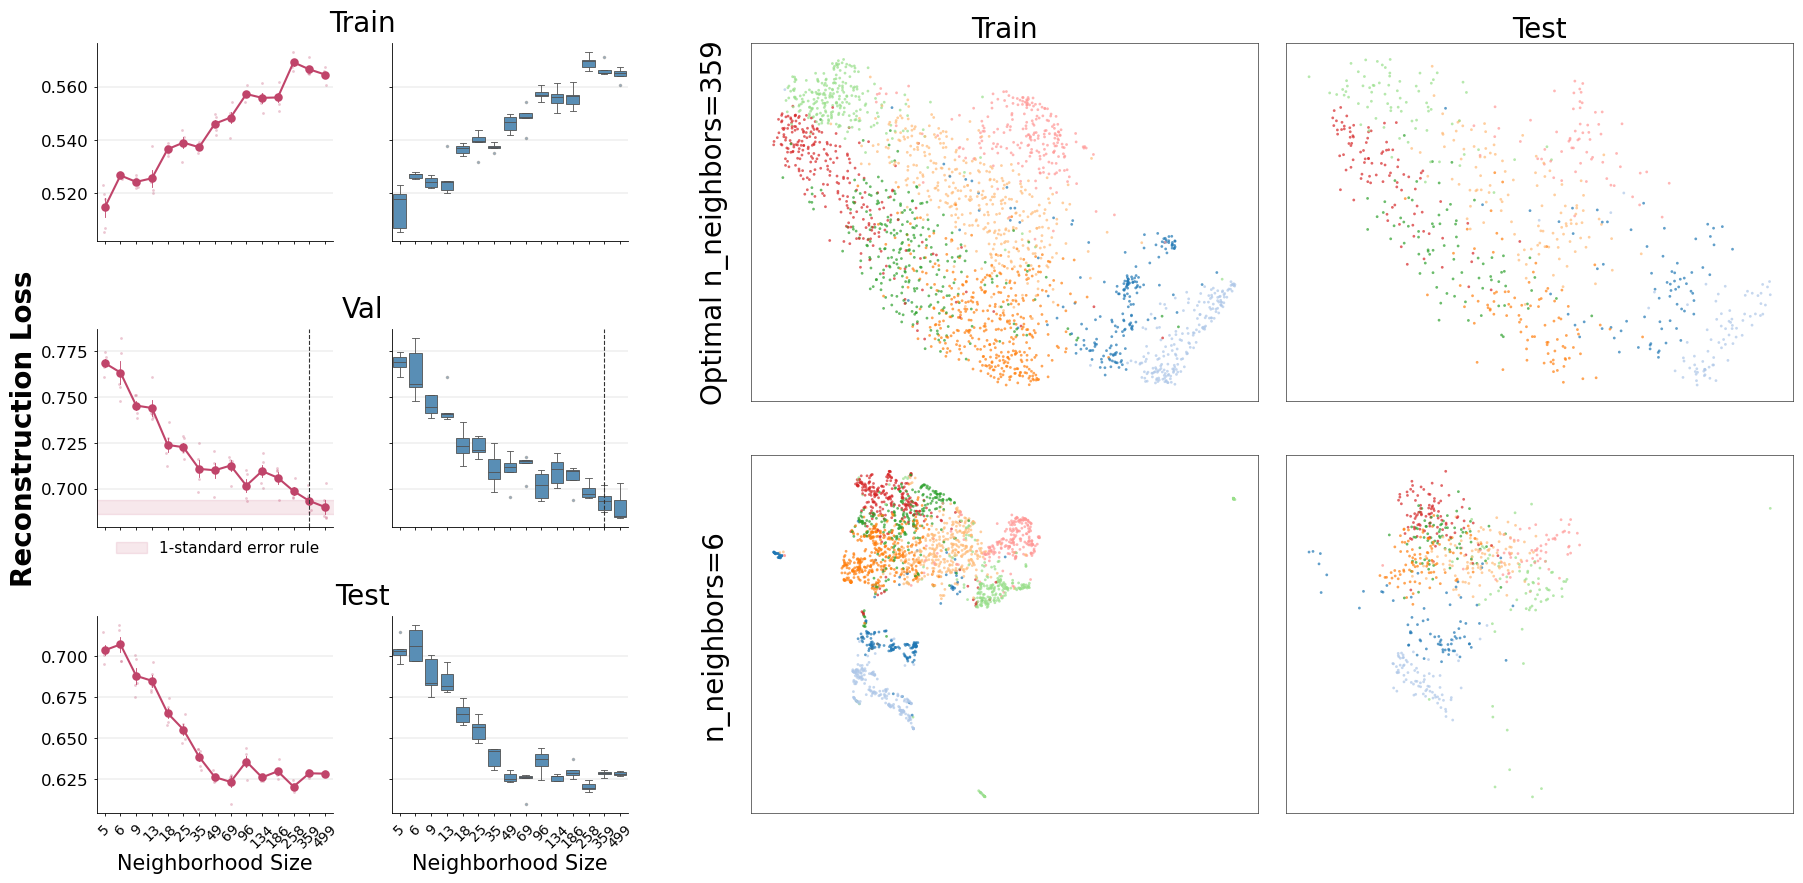

In [20]:
build_figure(
    analysis, 'n_neighbors', unique_neighbors, umap_one_std_range, vline_x,
    emb_data, list_umap_param, umap_one_std_param_choice,
    astro_palette, 'n_neighbors', 'Neighborhood Size',
    row_label_y=1.1,
    legend_kw={'frameon': False, 'fontsize': 11, 'loc': 'best', 'bbox_to_anchor': (1, 0)},
    xtick_fontsize=10, figsize=(22, 10)
)

In [27]:
astro_pca_res_dict = []
for s in range(5):
    student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/medal_pca2_2_seed{s}_ckpts/final.pt",
                                  input_dim=19,
                                  hidden_dims=[512] * 4,
                                  latent_dim=2, batchnorm=False)
    
    student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon.detach().numpy() - X)**2)
    astro_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
    val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
    astro_pca_res_dict.append({"recon_loss": val_recon, "split": "Val", "seed": s})

    x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    astro_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_37731/4110552109.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0


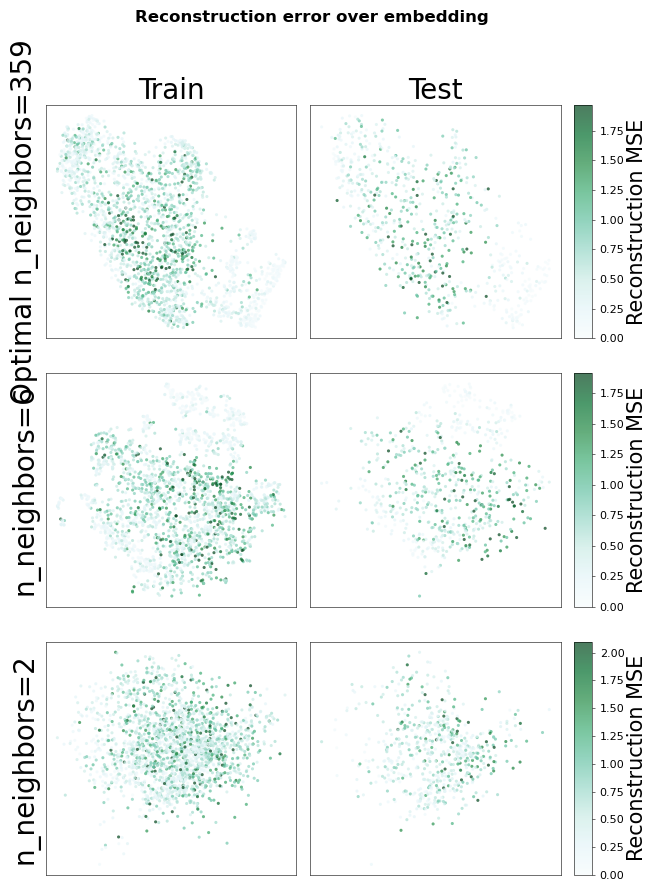

In [42]:
from utils import build_distortion_figure

student_pca = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/normalize/astro/medal_pca2_2_seed0_ckpts/final.pt',
                input_dim=19,
                hidden_dims=[512,512,512,512],
                latent_dim=2, batchnorm=False)
student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
student_recon_val_pca, student_embed_val_pca = student_pca(torch.tensor(X_val, dtype=torch.float32))
student_recon_test_pca, student_embed_test_pca = student_pca(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_pca = np.mean((student_recon_pca.detach().numpy() - X)**2, axis=1)
per_sample_recon_val_pca = np.mean((student_recon_val_pca.detach().numpy() - X_val)**2, axis=1)
per_sample_recon_test_pca = np.mean((student_recon_test_pca.detach().numpy() - X_test)**2, axis=1)

emb_data = {
    umap_one_std_param_choice: {
        'Train': (student_embed_umap01,      per_sample_recon_umap01,      y),
        'Val':   (student_embed_val_umap01,  per_sample_recon_val_umap01,  y_val),
        'Test':  (student_embed_test_umap01, per_sample_recon_test_umap01, y_test),
    },
    tsne_one_std_param_choice: {
        'Train': (student_embed_tsne01,      per_sample_recon_tsne01,      y),
        'Val':   (student_embed_val_tsne01,  per_sample_recon_val_tsne01,  y_val),
        'Test':  (student_embed_test_tsne01, per_sample_recon_test_tsne01, y_test),
    },
    2: {
        'Train': (student_embed_pca,      per_sample_recon_pca,      y),
        'Val':   (student_embed_val_pca,  per_sample_recon_val_pca,  y_val),
        'Test':  (student_embed_test_pca, per_sample_recon_test_pca, y_test),
    },
}

build_distortion_figure(
    emb_data, [umap_one_std_param_choice, tsne_one_std_param_choice, 2], umap_one_std_param_choice,
    param_label='n_neighbors', cmap=sns.color_palette("BuGn", as_cmap=True), figsize=(7, 10),
)

In [29]:
tsne_analysis = pd.DataFrame(astro_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Val'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(astro_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Val'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
pca_analysis = pd.DataFrame(astro_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Val'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_one_std_param_choice, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_one_std_param_choice})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_one_std_param_choice, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_one_std_param_choice})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, pca_best])

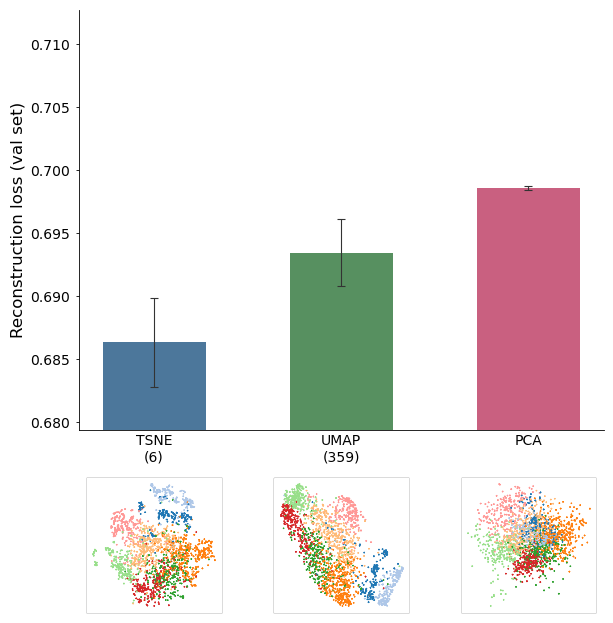

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# --- assumes embeddings dict like: {'TSNE(793)': Z_array, ...} ---
# Z_arrays should be (N,2) numpy arrays, already computed
embeddings = {
    f'TSNE(perplexity={tsne_one_std_param_choice})': np.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_tsne_{tsne_one_std_param_choice}_train.npy"),
    f'UMAP(n_neighbors={umap_one_std_param_choice})':np.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_umap_{umap_one_std_param_choice}_0.1_train.npy"),
    'PCA': np.load(Path(PATH_PREFIX) / f"drd_data/tmp_results/normalize/astro/embeddings/data_pca2_train.npy"),
}

method_order = [f'TSNE(perplexity={tsne_one_std_param_choice})', f'UMAP(n_neighbors={umap_one_std_param_choice})', 'PCA', ]

short_labels = {
    f'TSNE(perplexity={tsne_one_std_param_choice})':  f'TSNE\n({tsne_one_std_param_choice})',
    f'UMAP(n_neighbors={umap_one_std_param_choice})':  f'UMAP\n({umap_one_std_param_choice})',
    'PCA':                   'PCA',
}

# color palette — one color per method, muted
method_colors = {
    f'TSNE(perplexity={tsne_one_std_param_choice})':  '#2C5F8A',
    f'UMAP(n_neighbors={umap_one_std_param_choice})':  '#3A7D44',
    'PCA':                   '#C0446A',
}

# aggregate stats
stats = (teachers.groupby('method')['recon_loss']
         .agg(mean='mean', se=lambda x: x.sem())
         .reindex(method_order)
         .reset_index())

plt.rcParams.update({
    'font.family':          'sans-serif',
    'font.sans-serif':      ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':            8,
    'axes.labelsize':       10,
    'axes.titlesize':       12,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'axes.linewidth':       0.6,
    'xtick.major.width':    0.6,
    'ytick.major.width':    0.6,
    'xtick.major.size':     2.5,
    'ytick.major.size':     2.5,
    'pdf.fonttype':         42,
    'ps.fonttype':          42,
})

# extra bottom margin to accommodate the thumbnails
fig, ax = plt.subplots(figsize=(7, 7))   # bigger
fig.subplots_adjust(bottom=0.28)  

x = np.arange(len(method_order))
bar_w = 0.55

bars = ax.bar(
    x, stats['mean'],
    width=bar_w,
    color=[method_colors[m] for m in stats['method']],
    alpha=0.85,
    zorder=3,
)

ax.errorbar(
    x, stats['mean'],
    yerr=stats['se'],
    fmt='none',
    ecolor='#333333',
    elinewidth=0.8,
    capsize=3,
    capthick=0.8,
    zorder=4,
)

# spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.set_ylabel('Reconstruction loss (val set)', labelpad=4, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['' ] * len(method_order))  # blank out text
ax.tick_params(axis='x', length=0)             # hide tick marks too

# add method name as small text manually, below where thumbnail will sit
for i, method in enumerate(method_order):
    ax.text(i, -0.01, short_labels[method],
            ha='center', va='top',
            fontsize=10, 
            transform=ax.get_xaxis_transform())

# thumbnail loop — push further down and slightly bigger
thumb_zoom = 0.32
ymin = (stats['mean'] - stats['se']).min()
ax.set_ylim(ymin * 0.995, (stats['mean'] + stats['se']).max() * 1.02)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
fig.subplots_adjust(bottom=0.28, left=0.15)

for i, method in enumerate(method_order):
    Z = embeddings[method]

    fig_tmp, ax_tmp = plt.subplots(figsize=(3, 3))
    sns.scatterplot(x=Z[:, 0], y=Z[:, 1],
                    hue=y, palette=astro_palette, ax=ax_tmp,
                    legend=False, s=10,
                    linewidths=0, rasterized=True)
    ax_tmp.axis('off')
    fig_tmp.tight_layout(pad=0)
    fig_tmp.canvas.draw()
    img = np.asarray(fig_tmp.canvas.buffer_rgba())[..., :3]  # (H, W, 3)
    plt.close(fig_tmp)

    imagebox = OffsetImage(img, zoom=thumb_zoom)
    ab = AnnotationBbox(
        imagebox,
        xy=(i, 0),
        xycoords=('data', 'axes fraction'),
        box_alignment=(0.5, 1.0),
        xybox=(0, -35),                  # <-- push further down (was -18)
        boxcoords='offset points',
        frameon=True,
        bboxprops=dict(edgecolor='#cccccc', linewidth=0.5,
                       boxstyle='round,pad=0.1'),
    )
    ax.add_artist(ab)
plt.show()

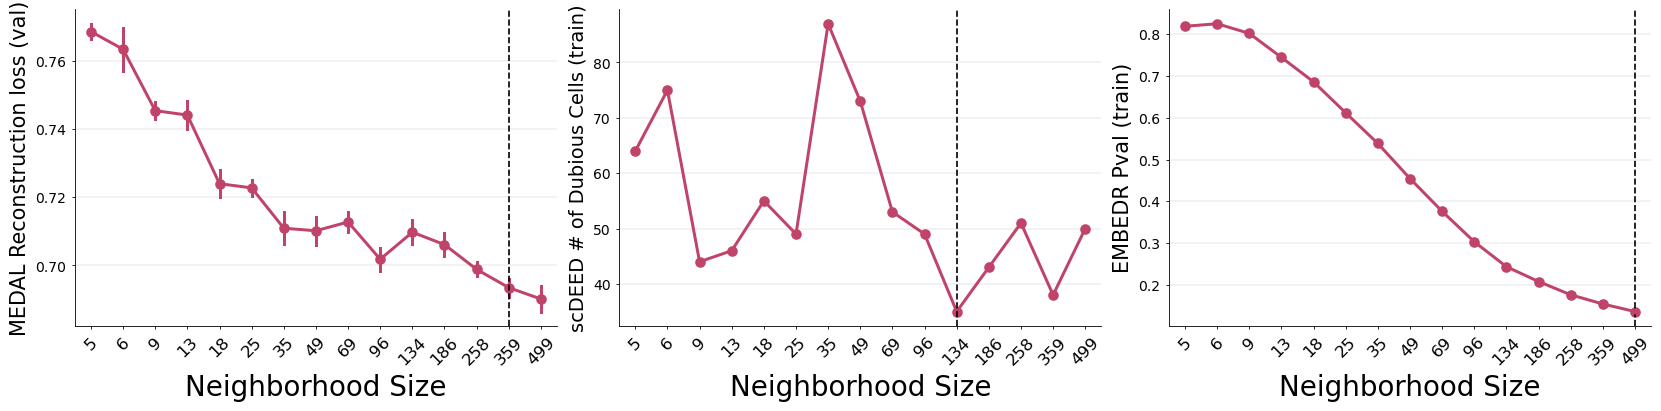

In [43]:
# other methods
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4), constrained_layout=True)
axes_flat = axes.flatten()

## MEDAL
analysis, umap_one_std_range, umap_one_std_param_choice, unique_nn, vline_x = \
    compute_param_choice(astro_umap_res_dict, 'n_neighbors')
sns.pointplot(data=analysis.loc[analysis.split == "Val"], x="n_neighbors", y="recon_loss", color="#C0446A", markersize=6, ax=axes_flat[0], 
              errorbar='se')
axes_flat[0].set_ylabel("MEDAL Reconstruction loss (val)", fontsize=15)
axes_flat[0].axvline(x=unique_nn.index(umap_one_std_param_choice), ls='--', c='black')

## scDEED
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_astro_train_num_dubious.csv')
umap_argmin = scdeed_analysis['number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(umap_argmin)
sns.pointplot(data=scdeed_analysis, x='n_neighbors', y='number_dubious_cells', color='#C0446A', markersize=6, ax=axes_flat[1])
axes_flat[1].axvline(x=argmin_position, ls='--', c='black')
axes_flat[1].set_ylabel("scDEED # of Dubious Cells (train)", fontsize=14)

## EMBEDR algorithm
embedr_ = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_umap_seed0/astro_train/elbow_df.csv')
embedr_.sort_values(by='n_neighbors', inplace=True)
embedr_umap_argmin = embedr_.groupby('n_neighbors')['mean_embedr_pval'].mean().idxmin()
unique_nn = sorted(embedr_['n_neighbors'].unique())
pos_mean = unique_nn.index(embedr_umap_argmin)
sns.pointplot(data=embedr_, x="n_neighbors", y="mean_embedr_pval", color="#C0446A", markersize=6, ax=axes_flat[2])
sns.stripplot(data=embedr_, x="n_neighbors", y="mean_embedr_pval", color="#C0446A", size=3, ax=axes_flat[2])
axes_flat[2].set_ylabel("EMBEDR Pval (train)", fontsize=15)
axes_flat[2].axvline(x=pos_mean, ls='--', c='black')

for ax in axes_flat:
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(0.6)
    ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=12)
    ax.set_xlabel("Neighborhood Size", fontsize=20)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='center')

plt.show()

In [ ]:
methods = ['scdeed', 'embedr']
scdeed_best, embedr_best = 499, 499

teacher_embed = dict.fromkeys(methods)
teacher_embed['scdeed'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/astro_train_umap_{scdeed_best}_0.1_0_train_pc6.npy")
teacher_embed['embedr'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/astro_umap_{embedr_best}_0.1_2_train_embedr.npy").squeeze(0)

embedr_df = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_umap_seed2/astro_train/X_with_best_scores.csv')
per_sample_embedr = embedr_df[f'embedr_pval_meanbest_{embedr_best}']

scdeed_df = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed0/umap_best_astro_train_full_results.csv", index_col=0)
per_sample_scdeed = split_scdeed_labels(scdeed_df, scdeed_best)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}

cmap = sns.color_palette("BuGn", as_cmap=True)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes_flat = axes.flatten()

# 1st column - MEDAL
medal_data_to_plot = (student_embed_umap01,  per_sample_recon_umap01,  y)
sns.scatterplot(x=medal_data_to_plot[0].detach().numpy()[:, 0],
                y=medal_data_to_plot[0].detach().numpy()[:, 1],
                s=4, hue=y, palette=mnist_palette, legend=False, ax=axes_flat[0])
sns.scatterplot(x=medal_data_to_plot[0].detach().numpy()[:, 0],
                y=medal_data_to_plot[0].detach().numpy()[:, 1],
                hue=medal_data_to_plot[1], palette=cmap,
                hue_norm=plt.Normalize(vmin=np.quantile(medal_data_to_plot[1], 0.025),
                                       vmax=np.quantile(medal_data_to_plot[1], 0.975)),
                s=20, legend=False, rasterized=True, ax=axes_flat[3])
axes_flat[0].set_title(f"MEDAL (n_neighbors={umap_one_std_param_choice})", fontsize=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=np.quantile(medal_data_to_plot[1], 0.025),
                                                          vmax=np.quantile(medal_data_to_plot[1], 0.975)))
cb = fig.colorbar(sm, ax=axes_flat[3], orientation="horizontal")
cb.set_label("reconstruction error", fontsize=20, labelpad=6)

# 2nd column - scDEED
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1],
                ax=axes_flat[1], s=8, hue=y_og, legend=False, palette=astro_palette)
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1],
                ax=axes_flat[4], s=20, hue=per_sample_scdeed, palette=palette_scdeed, legend=True)
handles, labels = axes_flat[4].get_legend_handles_labels()
if getattr(axes_flat[4], "legend_", None) is not None:
    axes_flat[4].legend_.remove()
    fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.03), frameon=True,
               title='Label', ncol=1, fontsize=18, markerscale=4, title_fontsize=18)
axes_flat[1].set_title(f"scDEED (n_neighbors={scdeed_best})", fontsize=20)

# 3rd column - EMBEDR
sns.scatterplot(x=teacher_embed['embedr'][:, 0], y=teacher_embed['embedr'][:, 1],
                s=4, hue=y_og, palette=astro_palette, legend=False, ax=axes_flat[2])
sns.scatterplot(x=teacher_embed['embedr'][:, 0], y=teacher_embed['embedr'][:, 1],
                hue=per_sample_embedr, palette=cmap,
                hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr, 0.025),
                                       vmax=np.quantile(per_sample_embedr, 0.975)),
                s=20, legend=False, rasterized=True, ax=axes_flat[5])
axes_flat[2].set_title(f"EMBEDR (n_neighbors={embedr_best})", fontsize=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=np.quantile(per_sample_embedr, 0.025),
                                                          vmax=np.quantile(per_sample_embedr, 0.975)))
cb = fig.colorbar(sm, ax=axes_flat[5], orientation="horizontal")
cb.set_label("p-values", fontsize=20, labelpad=6)

for ax in axes_flat:
    ax.set_yticks([])
    ax.set_xticks([])
plt.show()

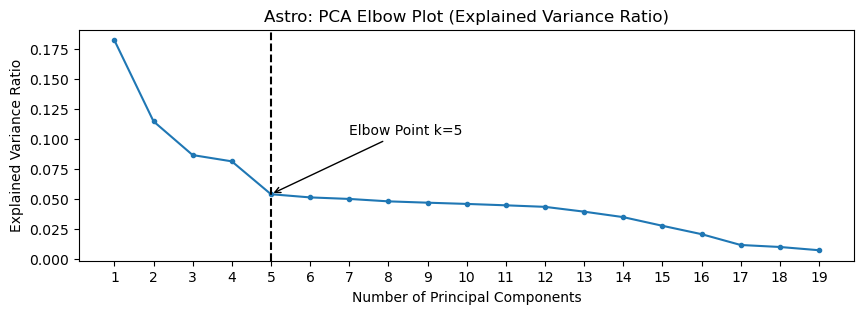

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
path = Path(PATH_PREFIX) / "MEDAL/comparisons/data/astro_train.csv"
df = pd.read_csv(path)

# Drop label column if present
cols_to_drop = ["label", "split"]

# Drop any non-numeric columns (e.g. split/train flags)
X = df.drop(columns=cols_to_drop)
X = X.select_dtypes(include=["number"])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)
explained_var = pca.explained_variance_ratio_

# Elbow plot: explained variance ratio
plt.figure(figsize=(10, 3))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', markersize=3)
plt.xlabel("Number of Principal Components")
plt.xticks(range(1, 20))
plt.ylabel("Explained Variance Ratio")
plt.axvline(x=5, ls='--', c='black')
# annotate the elbow point
plt.annotate('Elbow Point k=5', xy=(5, explained_var[4]), xytext =(7, explained_var[4]+0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),)
plt.title("Astro: PCA Elbow Plot (Explained Variance Ratio)")
plt.show()
